In [1]:
import json
import math
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Paths (relative to this notebook's location) ──────────────────────────
NOTEBOOK_DIR = Path("__file__").resolve().parent if "__file__" in dir() else Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "result_analysis" else NOTEBOOK_DIR

RESULTS_FILE = PROJECT_ROOT / "result_bank" / "simulated_solver_results" / "ArbitraryExperiment_1.json"
PLOTS_ROOT   = PROJECT_ROOT / "result_analysis" / "plots"

# ── Solver configuration ──────────────────────────────────────────────────
# Only S1 supports arbitrary partition sizes; S2/S3 require unit partitions.
SOLVERS = ["SQA"]

SOLVER_LABELS = {"SQA": "S1 (Arbitrary)"}
SOLVER_COLORS = {"SQA": "#2196F3"}
SOLVER_CMAPS  = {"SQA": "Blues"}
ILP_COLOR = "#9C27B0"

n_solvers = len(SOLVERS)
panel_width = 6

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Arbitrary-Partition Benchmark Analysis

Analysis of the baseline SQA formulation (S1) with variable partition sizes against an ILP baseline across the full Tier 1 grid (400 test cases).

- **S1 (Arbitrary):** One-hot k-safety + binary slack storage (Trummer baseline with arbitrary partition sizes)

S2 (Slack-Free) and S3 (Domain-Wall) are excluded because they require all partition sizes to be 1.

In [2]:
with open(RESULTS_FILE) as f:
    data = json.load(f)

meta = data["metadata"]
rows = []

for key, entry in data["results"].items():
    n_nodes = entry["n_nodes"]
    n_parts = entry["n_partitions"]
    assign_vars = n_nodes * n_parts
    ilp = entry["solvers"]["ILP"]

    for sn in SOLVERS:
        s = entry["solvers"].get(sn)
        if s is None:
            continue
        rows.append({
            "key": key,
            "n_nodes": n_nodes,
            "n_partitions": n_parts,
            "assign_vars": assign_vars,
            "solver": sn,
            "solver_label": SOLVER_LABELS[sn],
            "ilp_cost": ilp.get("cost"),
            "ilp_valid": ilp.get("valid", False),
            "cost": s.get("cost"),
            "valid": s.get("valid", False),
            "time_ms": s.get("time_ms"),
            "optimality_gap": s.get("optimality_gap"),
            "bqm_variables": s.get("bqm_variables"),
            "bqm_interactions": s.get("bqm_interactions"),
        })

df = pd.DataFrame(rows)

node_vals = sorted(df["n_nodes"].unique())
part_vals = sorted(df["n_partitions"].unique())
combo_counts = df.groupby(["n_nodes", "n_partitions", "solver"]).size().reset_index(name="count")
z = combo_counts["count"].mode().iloc[0] if len(combo_counts) > 0 else "?"

k_safety_val = next(iter(data["results"].values()))["k_safety"]

print(f"Loaded {len(data['results'])} test cases  ({len(node_vals)} node sizes × {len(part_vals)} partition sizes × {z} replicates)")
print(f"Node counts:      {node_vals}")
print(f"Partition counts: {part_vals}")
print(f"SQA params:       num_reads={meta['num_reads']}, num_sweeps={meta['num_sweeps']}")
print(f"k_safety={k_safety_val}")
print(f"Analysing solvers: {', '.join(SOLVER_LABELS[s] for s in SOLVERS)}")
df.head(3 * n_solvers)

Loaded 400 test cases  (5 node sizes × 8 partition sizes × 10 replicates)
Node counts:      [np.int64(2), np.int64(3), np.int64(5), np.int64(7), np.int64(9)]
Partition counts: [np.int64(3), np.int64(4), np.int64(8), np.int64(12), np.int64(18), np.int64(26), np.int64(36), np.int64(50)]
SQA params:       num_reads=1000, num_sweeps=1000
k_safety=2
Analysing solvers: S1 (Arbitrary)


,key,n_nodes,n_partitions,assign_vars,solver,solver_label,ilp_cost,ilp_valid,cost,valid,time_ms,optimality_gap,bqm_variables,bqm_interactions
0,n-2_p-12_1,2,12,24,SQA,S1 (Arbitrary),0.0,True,56,False,24056.0,NaN,40,392
1,n-2_p-12_10,2,12,24,SQA,S1 (Arbitrary),0.0,True,58,False,24093.3,NaN,40,392
2,n-2_p-12_2,2,12,24,SQA,S1 (Arbitrary),0.0,True,166,False,23977.4,NaN,40,392


## Helper Functions

In [3]:
def build_solver_grid(df, solver, value_col, agg="mean"):
    sub = df[df["solver"] == solver]
    pivot = sub.groupby(["n_nodes", "n_partitions"])[value_col].agg(agg).unstack("n_partitions")
    pivot = pivot.reindex(index=sorted(pivot.index), columns=sorted(pivot.columns))
    return pivot


def heatmap(ax, grid, title, fmt=".2f", cmap="RdYlGn", vmin=None, vmax=None,
            cbar_label="", show_cbar=True):
    im = ax.imshow(grid.values, aspect="auto", cmap=cmap,
                   vmin=vmin, vmax=vmax, origin="upper")
    ax.set_xticks(range(len(grid.columns)))
    ax.set_xticklabels(grid.columns, fontsize=8)
    ax.set_yticks(range(len(grid.index)))
    ax.set_yticklabels(grid.index, fontsize=8)
    ax.set_xlabel("Partition Count", fontsize=9)
    ax.set_ylabel("Node Count", fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold")
    for r in range(len(grid.index)):
        for c in range(len(grid.columns)):
            val = grid.values[r, c]
            if not np.isnan(val):
                ax.text(c, r, format(val, fmt), ha="center", va="center",
                        fontsize=7, color="black")
    if show_cbar:
        plt.colorbar(im, ax=ax, label=cbar_label, shrink=0.85)
    return im

## 1. Validity Rate Heatmap

Fraction of the 10 replicates at each (nodes, partitions) combination where the solver produced a constraint-satisfying solution.

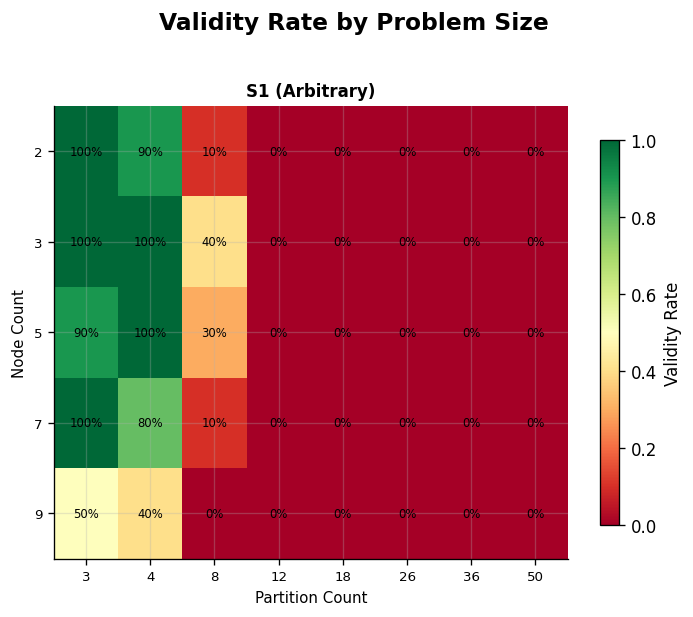

In [4]:
fig1, axes = plt.subplots(1, n_solvers, figsize=(panel_width * n_solvers, 5))
if n_solvers == 1: axes = [axes]
fig1.suptitle("Validity Rate by Problem Size", fontsize=14, fontweight="bold", y=1.02)

for ax, sn in zip(axes, SOLVERS):
    grid = build_solver_grid(df, sn, "valid", agg="mean")
    heatmap(ax, grid, SOLVER_LABELS[sn], fmt=".0%", cmap="RdYlGn",
            vmin=0, vmax=1, cbar_label="Validity Rate")

fig1.tight_layout()
plt.show()

## 2. Optimality Gap Heatmap

`(SQA cost - ILP cost) / ILP cost` averaged over valid replicates. Lower is better. Missing cells indicate no valid solutions at that size.

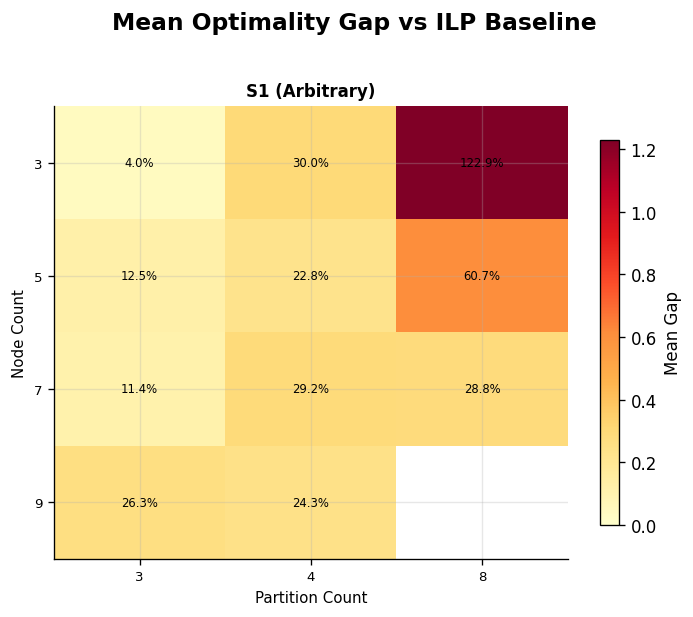

In [5]:
df_gap = df[df["valid"] & df["ilp_valid"]].dropna(subset=["optimality_gap"])

fig2, axes = plt.subplots(1, n_solvers, figsize=(panel_width * n_solvers, 5))
if n_solvers == 1: axes = [axes]
fig2.suptitle("Mean Optimality Gap vs ILP Baseline", fontsize=14, fontweight="bold", y=1.02)

all_grids = []
for sn in SOLVERS:
    g = build_solver_grid(df_gap, sn, "optimality_gap", agg="mean")
    all_grids.append(g)
vmax = max(g.max().max() for g in all_grids if not g.empty)

for ax, sn, grid in zip(axes, SOLVERS, all_grids):
    heatmap(ax, grid, SOLVER_LABELS[sn], fmt=".1%", cmap="YlOrRd",
            vmin=0, vmax=vmax, cbar_label="Mean Gap")

fig2.tight_layout()
plt.show()

## 3. Solve Time Heatmap

Mean SQA solve time in milliseconds.

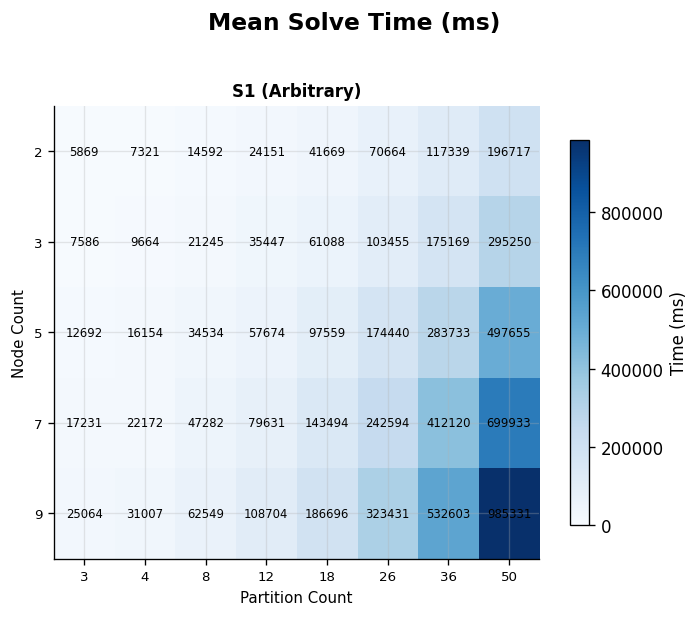

In [6]:
fig4, axes = plt.subplots(1, n_solvers, figsize=(panel_width * n_solvers, 5))
if n_solvers == 1: axes = [axes]
fig4.suptitle("Mean Solve Time (ms)", fontsize=14, fontweight="bold", y=1.02)

time_grids = [build_solver_grid(df, sn, "time_ms", agg="mean") for sn in SOLVERS]
vmax_t = max(g.max().max() for g in time_grids if not g.empty)

for ax, sn, grid in zip(axes, SOLVERS, time_grids):
    heatmap(ax, grid, SOLVER_LABELS[sn], fmt=".0f", cmap=SOLVER_CMAPS[sn],
            vmin=0, vmax=vmax_t, cbar_label="Time (ms)")

fig4.tight_layout()
plt.show()

## 4. BQM Size

Number of BQM variables and quadratic interactions at each problem size. With arbitrary partition sizes, slack variable counts depend on the Mersenne-rounded capacities, which vary per test case.

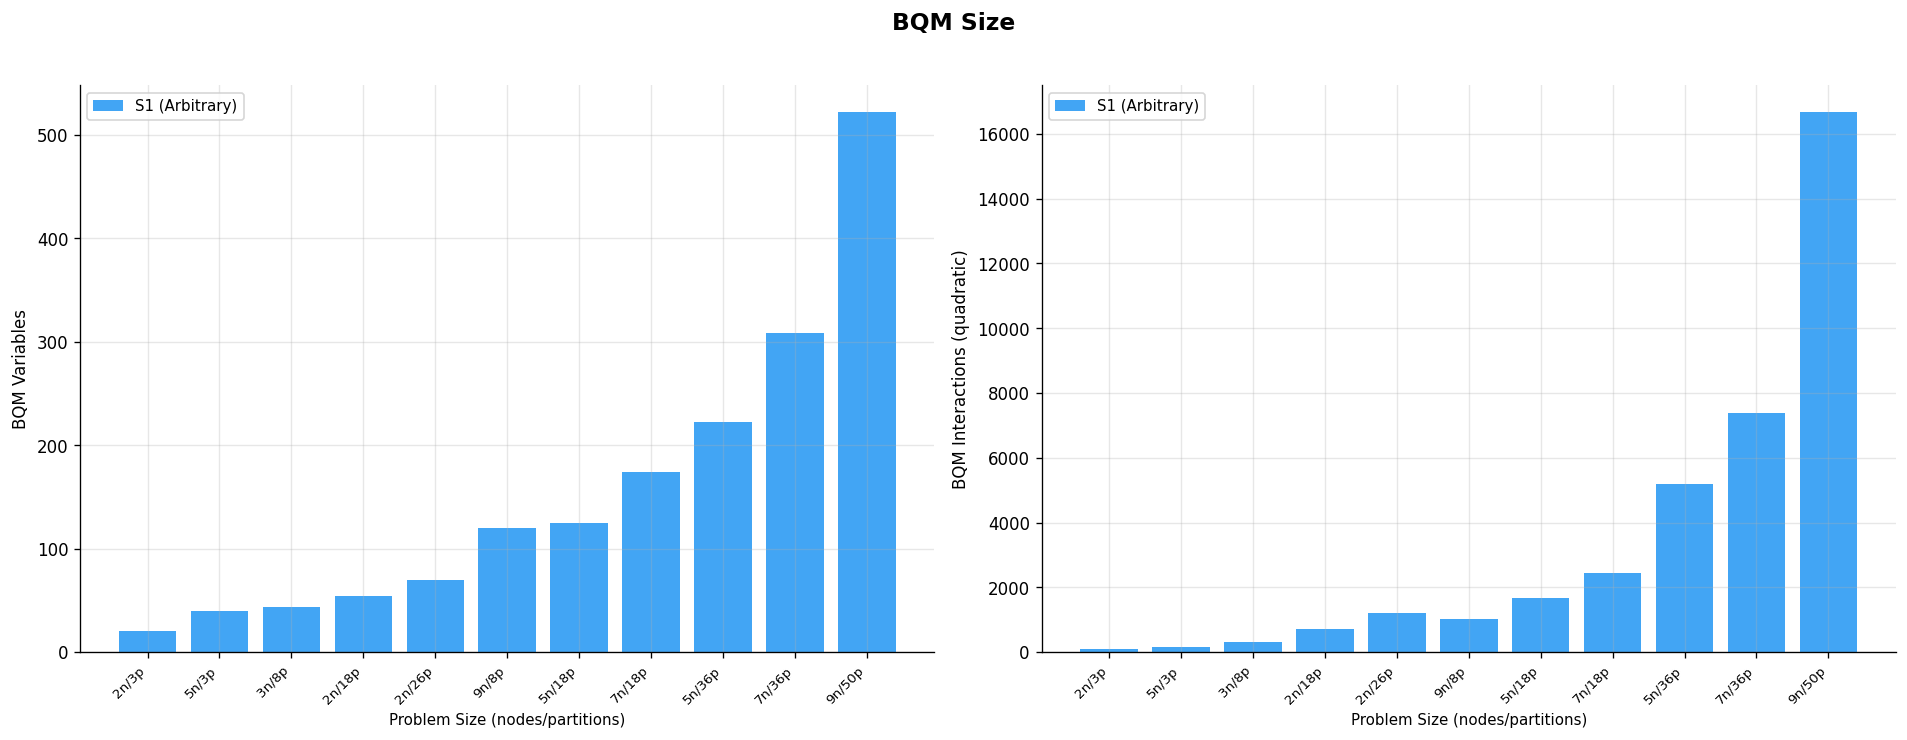

In [7]:
bqm_rows = []
for sn in SOLVERS:
    sub = df[df["solver"] == sn].dropna(subset=["bqm_variables"])
    rep = sub.drop_duplicates(subset=["n_nodes", "n_partitions"]).sort_values(["n_nodes", "n_partitions"])
    for _, row in rep.iterrows():
        bqm_rows.append({
            "size_label": f"{row['n_nodes']}n/{row['n_partitions']}p",
            "assign_vars": row["assign_vars"],
            "solver": sn,
            "bqm_variables": row["bqm_variables"],
            "bqm_interactions": row["bqm_interactions"],
        })

df_bqm = pd.DataFrame(bqm_rows)

unique_sizes = df_bqm.drop_duplicates("size_label").sort_values("assign_vars")
if len(unique_sizes) > 12:
    step = len(unique_sizes) // 10
    keep_labels = unique_sizes.iloc[::step]["size_label"].tolist()
    if unique_sizes.iloc[-1]["size_label"] not in keep_labels:
        keep_labels.append(unique_sizes.iloc[-1]["size_label"])
    df_bqm_plot = df_bqm[df_bqm["size_label"].isin(keep_labels)]
else:
    df_bqm_plot = df_bqm

fig5, (ax_v, ax_i) = plt.subplots(1, 2, figsize=(16, 6))
fig5.suptitle("BQM Size", fontsize=14, fontweight="bold", y=1.02)

size_labels_ordered = df_bqm_plot.drop_duplicates("size_label").sort_values("assign_vars")["size_label"].tolist()
x_pos = np.arange(len(size_labels_ordered))
bar_w = 0.8 / max(n_solvers, 1)

for panel_idx, (ax, col, ylabel) in enumerate([
    (ax_v, "bqm_variables", "BQM Variables"),
    (ax_i, "bqm_interactions", "BQM Interactions (quadratic)"),
]):
    for i, sn in enumerate(SOLVERS):
        offset = (i - (n_solvers - 1) / 2) * bar_w
        vals = []
        for sl in size_labels_ordered:
            row = df_bqm_plot[(df_bqm_plot["solver"] == sn) & (df_bqm_plot["size_label"] == sl)]
            vals.append(row[col].values[0] if len(row) > 0 else 0)
        ax.bar(x_pos + offset, vals, bar_w,
               label=SOLVER_LABELS[sn], color=SOLVER_COLORS[sn], alpha=0.85)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(size_labels_ordered, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xlabel("Problem Size (nodes/partitions)", fontsize=9)
    ax.legend(fontsize=9)

fig5.tight_layout()
plt.show()

## 5. Head-to-Head: Pairwise Gap Comparison

*Skipped — only one SQA solver in this benchmark. This section is included for structural parity with the unit-partition analysis and will populate automatically if additional solvers are added to `SOLVERS`.*

In [8]:
from itertools import combinations

pairs = list(combinations(SOLVERS, 2))
n_pairs = len(pairs)

if n_pairs > 0:
    fig6, axes = plt.subplots(1, n_pairs, figsize=(6 * n_pairs, 5.5), squeeze=False)
    axes = axes.flatten()
    fig6.suptitle("Head-to-Head Optimality Gap (same test case, both valid)", fontsize=14, fontweight="bold", y=1.02)

    for ax, (a, b) in zip(axes, pairs):
        da = df_gap[df_gap["solver"] == a][["key", "optimality_gap"]].rename(columns={"optimality_gap": "gap_a"})
        db = df_gap[df_gap["solver"] == b][["key", "optimality_gap"]].rename(columns={"optimality_gap": "gap_b"})
        merged = da.merge(db, on="key", how="inner")

        if len(merged) > 0:
            ax.scatter(merged["gap_a"], merged["gap_b"],
                       alpha=0.4, s=30, color="#555555", edgecolors="white", linewidths=0.3)
            lim = max(merged["gap_a"].max(), merged["gap_b"].max()) * 1.05
            ax.plot([0, lim], [0, lim], "k--", linewidth=0.8, alpha=0.5, label="Equal")
            ax.set_xlim(-0.01, lim)
            ax.set_ylim(-0.01, lim)
            a_wins = (merged["gap_a"] < merged["gap_b"]).sum()
            b_wins = (merged["gap_b"] < merged["gap_a"]).sum()
            ties = (merged["gap_a"] == merged["gap_b"]).sum()
            ax.text(0.05, 0.95,
                    f"{SOLVER_LABELS[a]} wins: {a_wins}\n{SOLVER_LABELS[b]} wins: {b_wins}\nTies: {ties}",
                    transform=ax.transAxes, fontsize=8, va="top",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        ax.set_xlabel(f"{SOLVER_LABELS[a]} gap", fontsize=10)
        ax.set_ylabel(f"{SOLVER_LABELS[b]} gap", fontsize=10)
        ax.set_title(f"{SOLVER_LABELS[a]} vs {SOLVER_LABELS[b]}  (n={len(merged)})", fontsize=10)
        ax.legend(fontsize=8)
        ax.set_aspect("equal")
    fig6.tight_layout()
    plt.show()
else:
    fig6 = plt.figure()
    print("Only one solver selected — head-to-head comparison requires at least two.")

Only one solver selected — head-to-head comparison requires at least two.


<Figure size 768x576 with 0 Axes>

## 6. Validity Rate vs Partition Count

One panel per node count. Shows how the solver's ability to find feasible solutions degrades as the number of partitions grows.

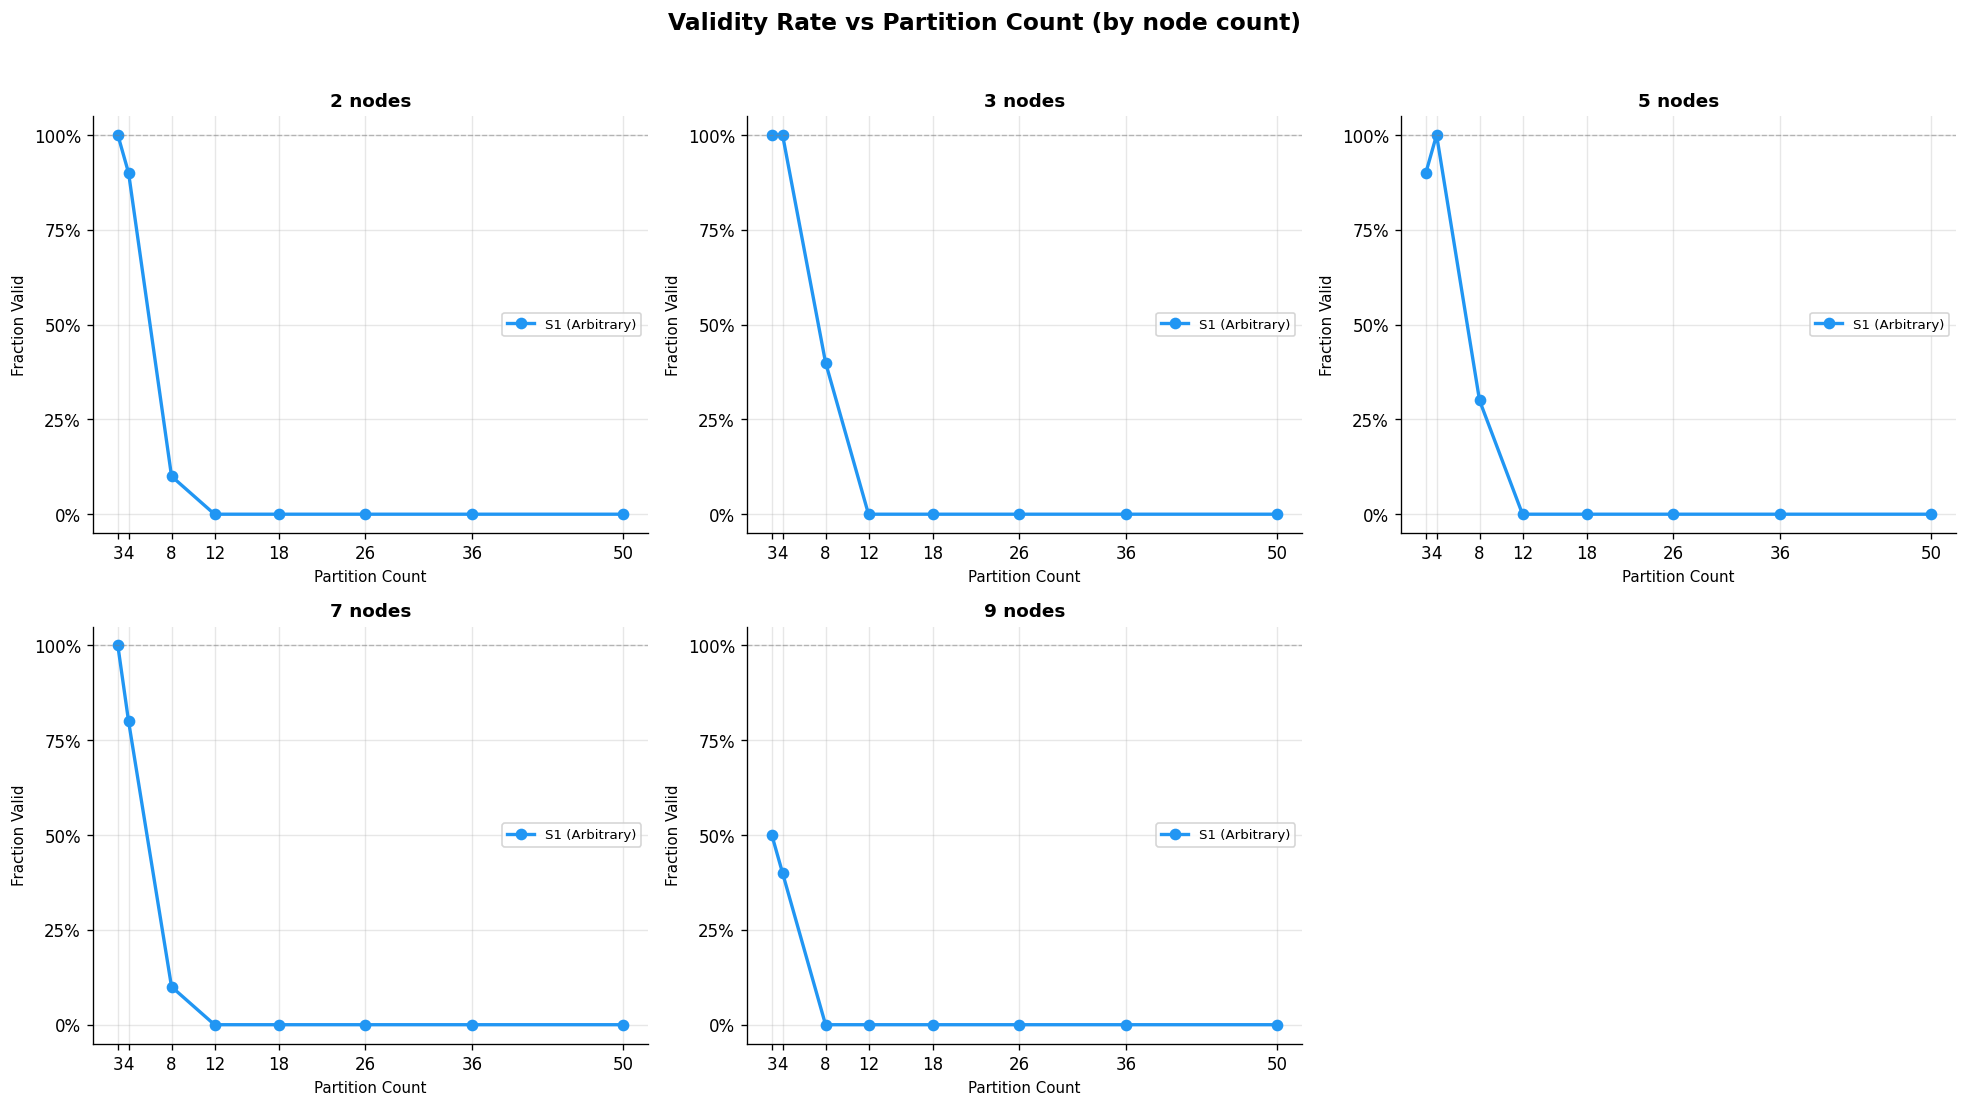

In [9]:
n_panels = len(node_vals)
ncols = min(n_panels, 3)
nrows = math.ceil(n_panels / ncols)

fig7, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.5 * nrows), squeeze=False)
fig7.suptitle("Validity Rate vs Partition Count (by node count)", fontsize=14, fontweight="bold", y=1.02)

validity = df.groupby(["n_nodes", "n_partitions", "solver"])["valid"].mean().reset_index()

for idx, n in enumerate(node_vals):
    ax = axes.flatten()[idx]
    for sn in SOLVERS:
        sub = validity[(validity["n_nodes"] == n) & (validity["solver"] == sn)].sort_values("n_partitions")
        ax.plot(sub["n_partitions"], sub["valid"], "o-",
                color=SOLVER_COLORS[sn], linewidth=2, markersize=6,
                label=SOLVER_LABELS[sn])

    ax.set_title(f"{n} nodes", fontsize=11, fontweight="bold")
    ax.set_xlabel("Partition Count", fontsize=9)
    ax.set_ylabel("Fraction Valid", fontsize=9)
    ax.set_ylim(-0.05, 1.05)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.axhline(1.0, color="grey", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_xticks(sorted(sub["n_partitions"].unique()))
    ax.legend(fontsize=8)

for ax in axes.flatten()[n_panels:]:
    ax.set_visible(False)

fig7.tight_layout()
plt.show()

## 7. Scaling Analysis

Mean validity rate and mean optimality gap plotted against total assignment variables (|P| × |N|).

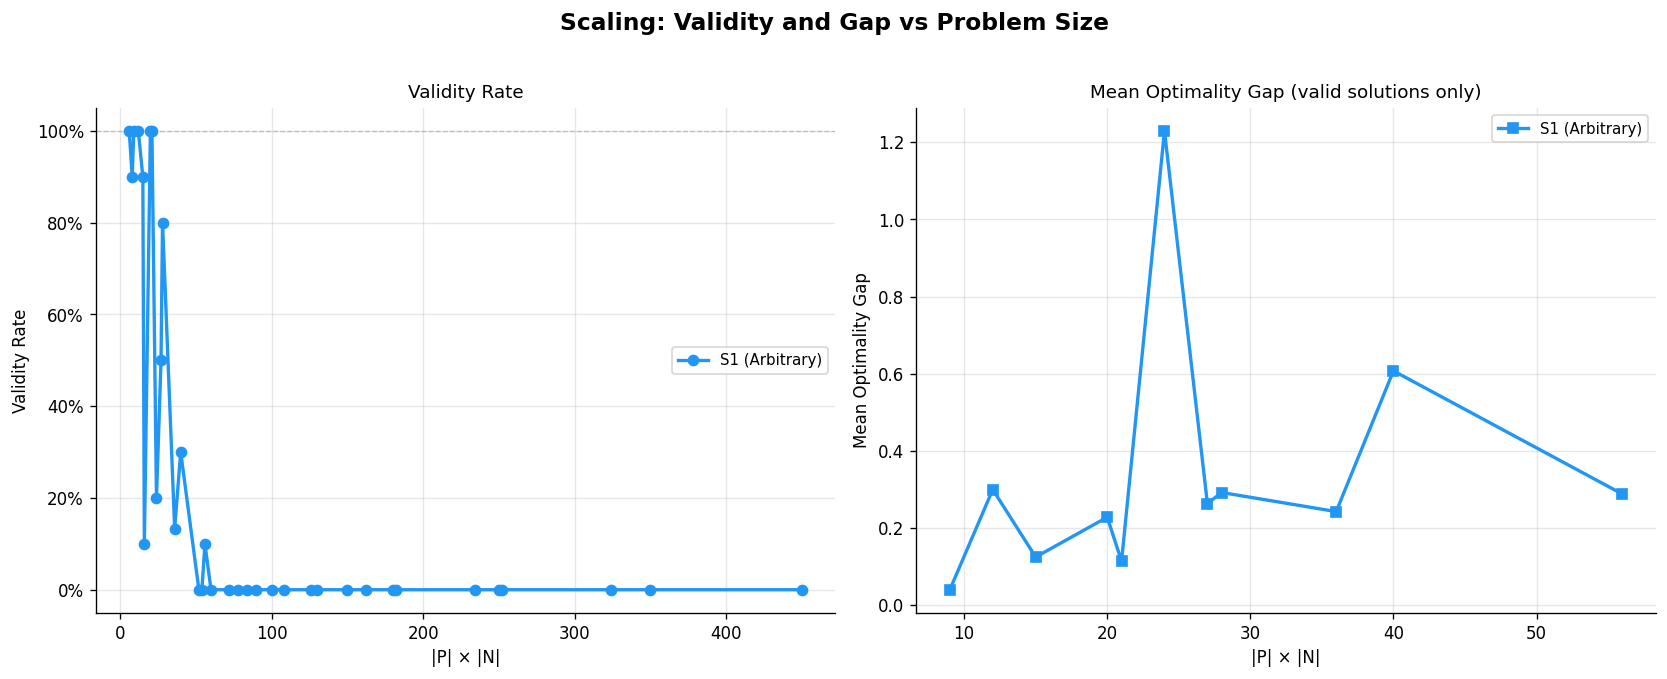

In [10]:
fig8, (ax_val, ax_gap) = plt.subplots(1, 2, figsize=(14, 5.5))
fig8.suptitle("Scaling: Validity and Gap vs Problem Size", fontsize=14, fontweight="bold", y=1.02)

scale_val = df.groupby(["assign_vars", "solver"])["valid"].mean().reset_index()
scale_gap = df_gap.groupby(["assign_vars", "solver"])["optimality_gap"].mean().reset_index()

for sn in SOLVERS:
    sv = scale_val[scale_val["solver"] == sn].sort_values("assign_vars")
    ax_val.plot(sv["assign_vars"], sv["valid"], "o-",
                color=SOLVER_COLORS[sn], linewidth=2, markersize=6,
                label=SOLVER_LABELS[sn])

    sg = scale_gap[scale_gap["solver"] == sn].sort_values("assign_vars")
    ax_gap.plot(sg["assign_vars"], sg["optimality_gap"], "s-",
                color=SOLVER_COLORS[sn], linewidth=2, markersize=6,
                label=SOLVER_LABELS[sn])

ax_val.set_xlabel("|P| × |N|", fontsize=10)
ax_val.set_ylabel("Validity Rate", fontsize=10)
ax_val.set_ylim(-0.05, 1.05)
ax_val.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax_val.axhline(1.0, color="grey", linewidth=0.8, linestyle="--", alpha=0.4)
ax_val.legend(fontsize=9)
ax_val.set_title("Validity Rate", fontsize=11)

ax_gap.set_xlabel("|P| × |N|", fontsize=10)
ax_gap.set_ylabel("Mean Optimality Gap", fontsize=10)
ax_gap.legend(fontsize=9)
ax_gap.set_title("Mean Optimality Gap (valid solutions only)", fontsize=11)

fig8.tight_layout()
plt.show()

## 8. Aggregate Summary

Overall validity rate, mean gap, and mean solve time across all 400 test cases.

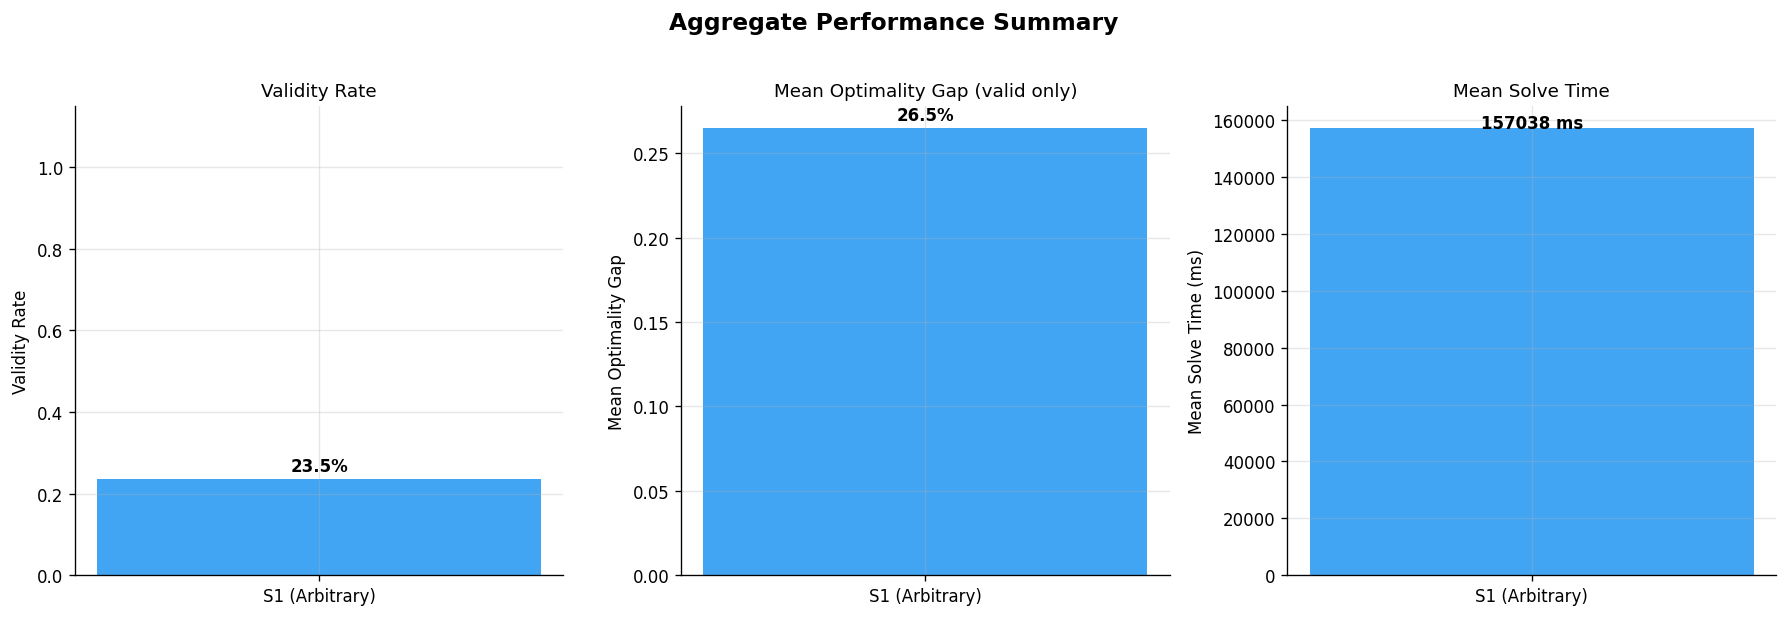

In [11]:
fig11, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
fig11.suptitle("Aggregate Performance Summary", fontsize=14, fontweight="bold", y=1.02)

# Validity
vals = [df[df["solver"] == sn]["valid"].mean() for sn in SOLVERS]
bars1 = ax1.bar([SOLVER_LABELS[sn] for sn in SOLVERS], vals,
                color=[SOLVER_COLORS[sn] for sn in SOLVERS], alpha=0.85)
for bar, v in zip(bars1, vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{v:.1%}", ha="center", fontsize=10, fontweight="bold")
ax1.set_ylabel("Validity Rate", fontsize=10)
ax1.set_ylim(0, 1.15)
ax1.set_title("Validity Rate", fontsize=11)

# Mean gap
gaps = [df_gap[df_gap["solver"] == sn]["optimality_gap"].mean() for sn in SOLVERS]
bars2 = ax2.bar([SOLVER_LABELS[sn] for sn in SOLVERS], gaps,
                color=[SOLVER_COLORS[sn] for sn in SOLVERS], alpha=0.85)
for bar, v in zip(bars2, gaps):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{v:.1%}", ha="center", fontsize=10, fontweight="bold")
ax2.set_ylabel("Mean Optimality Gap", fontsize=10)
ax2.set_title("Mean Optimality Gap (valid only)", fontsize=11)

# Mean time
times = [df[df["solver"] == sn]["time_ms"].mean() for sn in SOLVERS]
bars3 = ax3.bar([SOLVER_LABELS[sn] for sn in SOLVERS], times,
                color=[SOLVER_COLORS[sn] for sn in SOLVERS], alpha=0.85)
for bar, v in zip(bars3, times):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f"{v:.0f} ms", ha="center", fontsize=10, fontweight="bold")
ax3.set_ylabel("Mean Solve Time (ms)", fontsize=10)
ax3.set_title("Mean Solve Time", fontsize=11)

fig11.tight_layout()
plt.show()

## 9. Physical Qubit Requirements Across D-Wave Topologies

Degree-based lower bound on physical qubits for the S1 (arbitrary partition) formulation. With variable partition sizes, the storage constraint's slack variables depend on Mersenne-rounded capacities, which are themselves a function of the partition sizes assigned to each node.

| Chip | Topology | Qubits | Degree |
|---|---|---|---|
| DW 2000Q | Chimera C16 | 2,048 | 6 |
| Advantage | Pegasus P16 | 5,640 | 15 |
| Advantage2 | Zephyr Z15 | 7,440 | 20 |

In [ ]:
import math

HW_CHIPS = {
    "DW_2000Q":   {"label": "DW 2000Q (Chimera)",   "degree": 6,  "qubits": 2048},
    "Advantage":  {"label": "Advantage (Pegasus)",   "degree": 15, "qubits": 5640},
    "Advantage2": {"label": "Advantage2 (Zephyr)",   "degree": 20, "qubits": 7440},
}

def degree_lb(num_vars, max_deg, hw_deg):
    if num_vars == 0 or hw_deg == 0:
        return num_vars
    return num_vars * max(1, math.ceil(max_deg / hw_deg))

# For arbitrary partitions we read BQM stats directly from the results
# rather than computing analytically (partition sizes vary per test case).
qubit_rows = []
for sn in SOLVERS:
    sub = df[df["solver"] == sn].dropna(subset=["bqm_variables", "bqm_interactions"])
    # One representative per (n, p)
    rep = sub.drop_duplicates(subset=["n_nodes", "n_partitions"]).sort_values(["n_nodes", "n_partitions"])
    for _, row in rep.iterrows():
        bqm_vars = int(row["bqm_variables"])
        bqm_ints = int(row["bqm_interactions"])
        # Estimate max degree: for S1, max_degree ≈ max interactions per variable
        # Upper bound: assume densest variable has degree ≈ 2 * bqm_ints / bqm_vars
        # More precise: (|N|-1) + (|P|-1) + slack_bits gives a lower bound
        # We use the empirical ratio as a practical estimate
        max_deg = math.ceil(2 * bqm_ints / bqm_vars) if bqm_vars > 0 else 0

        r = {
            "n_nodes": int(row["n_nodes"]),
            "n_partitions": int(row["n_partitions"]),
            "assign_vars": int(row["assign_vars"]),
            "solver": sn,
            "bqm_vars": bqm_vars,
            "bqm_interactions": bqm_ints,
            "max_degree": max_deg,
        }
        for chip_name, chip in HW_CHIPS.items():
            lb = degree_lb(bqm_vars, max_deg, chip["degree"])
            r[f"lb_{chip_name}"] = lb
            r[f"fits_{chip_name}"] = lb <= chip["qubits"]
            r[f"chain_lb_{chip_name}"] = max(1, math.ceil(max_deg / chip["degree"]))
        qubit_rows.append(r)

df_qubit = pd.DataFrame(qubit_rows)
print(f"Computed qubit stats for {len(df_qubit)} (size, solver) combinations")
df_qubit.head(6)

### 9a. Physical Qubit Lower Bounds — Heatmaps

Degree-based lower bound on physical qubits per (nodes, partitions) combination.

In [ ]:
chip_names = list(HW_CHIPS.keys())

for chip_name in chip_names:
    chip = HW_CHIPS[chip_name]
    fig_q, axes = plt.subplots(1, n_solvers, figsize=(panel_width * n_solvers, 5))
    if n_solvers == 1: axes = [axes]
    fig_q.suptitle(f"Physical Qubit Lower Bound — {chip['label']}  ({chip['qubits']:,} qubits, degree {chip['degree']})",
                   fontsize=14, fontweight="bold", y=1.02)

    col = f"lb_{chip_name}"
    vmax_q = df_qubit[col].max()

    for ax, sn in zip(axes, SOLVERS):
        sub = df_qubit[df_qubit["solver"] == sn]
        pivot = sub.pivot_table(index="n_nodes", columns="n_partitions", values=col, aggfunc="first")
        pivot = pivot.reindex(index=sorted(pivot.index), columns=sorted(pivot.columns))

        im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=vmax_q, origin="upper")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns, fontsize=8)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index, fontsize=8)
        ax.set_xlabel("Partition Count", fontsize=9)
        ax.set_ylabel("Node Count", fontsize=9)
        ax.set_title(SOLVER_LABELS[sn], fontsize=10, fontweight="bold")

        for r in range(len(pivot.index)):
            for c in range(len(pivot.columns)):
                val = pivot.values[r, c]
                if not np.isnan(val):
                    color = "red" if val > chip["qubits"] else "black"
                    marker = "!" if val > chip["qubits"] else ""
                    ax.text(c, r, f"{int(val)}{marker}", ha="center", va="center",
                            fontsize=7, color=color, fontweight="bold" if marker else "normal")

        plt.colorbar(im, ax=ax, label="Physical Qubits (LB)", shrink=0.85)

    fig_q.tight_layout()
    plt.show()

### 9b. Qubit Requirements — Largest Problem Sizes

Bar chart comparing the degree-based physical qubit lower bound across all three topologies for the largest problem sizes.

In [ ]:
large_sizes = df_qubit.drop_duplicates(["n_nodes", "n_partitions"]).nlargest(8, "assign_vars")
large_combos = list(zip(large_sizes["n_nodes"], large_sizes["n_partitions"]))

fig_qbar, axes = plt.subplots(1, n_solvers, figsize=(panel_width * n_solvers, 6), sharey=True)
if n_solvers == 1: axes = [axes]
fig_qbar.suptitle("Physical Qubit Lower Bounds — Largest Problem Sizes", fontsize=14, fontweight="bold", y=1.02)

chip_colors = {"DW_2000Q": "#e74c3c", "Advantage": "#3498db", "Advantage2": "#2ecc71"}

for ax, sn in zip(axes, SOLVERS):
    sub = df_qubit[df_qubit["solver"] == sn]
    sub = sub[sub.apply(lambda r: (r["n_nodes"], r["n_partitions"]) in large_combos, axis=1)]
    sub = sub.sort_values("assign_vars")

    labels = [f"{r['n_nodes']}n/{r['n_partitions']}p" for _, r in sub.iterrows()]
    x = np.arange(len(labels))
    w = 0.25

    for i, (chip_name, chip) in enumerate(HW_CHIPS.items()):
        vals = sub[f"lb_{chip_name}"].values
        bars = ax.bar(x + (i-1)*w, vals, w, label=chip["label"],
                      color=chip_colors[chip_name], alpha=0.85)
        ax.axhline(chip["qubits"], color=chip_colors[chip_name], linestyle="--",
                   linewidth=0.8, alpha=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_title(SOLVER_LABELS[sn], fontsize=11, fontweight="bold")
    ax.set_xlabel("Problem Size", fontsize=9)
    if ax == axes[0]:
        ax.set_ylabel("Physical Qubits (Lower Bound)", fontsize=10)
    ax.legend(fontsize=8)

fig_qbar.tight_layout()
plt.show()

### 9c. BQM Maximum Degree Scaling

The maximum degree of the interaction graph determines chain length requirements on hardware.

In [ ]:
fig_deg, (ax_deg, ax_ratio) = plt.subplots(1, 2, figsize=(14, 5.5))
fig_deg.suptitle("BQM Interaction Graph — Degree Analysis", fontsize=14, fontweight="bold", y=1.02)

for sn in SOLVERS:
    sub = df_qubit[df_qubit["solver"] == sn].sort_values("assign_vars")
    ax_deg.plot(sub["assign_vars"], sub["max_degree"], "o-",
                color=SOLVER_COLORS[sn], linewidth=2, markersize=5,
                label=SOLVER_LABELS[sn])

ax_deg.set_xlabel("|P| × |N|", fontsize=10)
ax_deg.set_ylabel("Max Degree", fontsize=10)
ax_deg.set_title("Maximum Variable Degree", fontsize=11)
ax_deg.legend(fontsize=9)

for sn in SOLVERS:
    sub = df_qubit[df_qubit["solver"] == sn].sort_values("assign_vars")
    chain_lb = np.ceil(sub["max_degree"].values / 20).astype(int)
    ax_ratio.plot(sub["assign_vars"], chain_lb, "o-",
                  color=SOLVER_COLORS[sn], linewidth=2, markersize=5,
                  label=SOLVER_LABELS[sn])

ax_ratio.set_xlabel("|P| × |N|", fontsize=10)
ax_ratio.set_ylabel("Min Chain Length", fontsize=10)
ax_ratio.set_title("Minimum Chain Length on Advantage2 (Zephyr, deg-20)", fontsize=11)
ax_ratio.axhline(1, color="grey", linestyle="--", linewidth=0.8, alpha=0.5, label="Ideal (no chains)")
ax_ratio.legend(fontsize=9)

fig_deg.tight_layout()
plt.show()

### 9d. Hardware Feasibility Summary

Largest problem size whose qubit lower bound fits within each chip's capacity.

In [ ]:
feasibility = []
for sn in SOLVERS:
    sub = df_qubit[df_qubit["solver"] == sn].sort_values("assign_vars")
    row = {"Solver": SOLVER_LABELS[sn]}
    for chip_name, chip in HW_CHIPS.items():
        fits = sub[sub[f"fits_{chip_name}"]]
        if len(fits) > 0:
            best = fits.iloc[-1]
            row[chip["label"]] = f"{int(best['n_nodes'])}n/{int(best['n_partitions'])}p ({int(best['assign_vars'])} vars → {int(best[f'lb_{chip_name}'])} qubits)"
        else:
            row[chip["label"]] = "None fit"
    feasibility.append(row)

df_feas = pd.DataFrame(feasibility).set_index("Solver")
print("Largest problem size fitting on each chip (by degree lower bound):\n")
df_feas

### 9e. Qubit Overhead Ratio

Physical-to-logical qubit ratio (lower bound) across problem sizes. A ratio of 1.0 means each logical variable maps to exactly one physical qubit (ideal).

In [ ]:
fig_eff, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig_eff.suptitle("Physical / Logical Qubit Ratio (Lower Bound)", fontsize=14, fontweight="bold", y=1.02)

for ax, (chip_name, chip) in zip(axes, HW_CHIPS.items()):
    for sn in SOLVERS:
        sub = df_qubit[df_qubit["solver"] == sn].sort_values("assign_vars")
        ratio = sub[f"lb_{chip_name}"] / sub["bqm_vars"]
        ax.plot(sub["assign_vars"], ratio, "o-",
                color=SOLVER_COLORS[sn], linewidth=2, markersize=5,
                label=SOLVER_LABELS[sn])

    ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5, label="1:1 (no chains)")
    ax.set_xlabel("|P| × |N|", fontsize=10)
    ax.set_ylabel("Physical / Logical Ratio", fontsize=10)
    ax.set_title(f"{chip['label']} (degree {chip['degree']})", fontsize=10, fontweight="bold")
    ax.legend(fontsize=8)

fig_eff.tight_layout()
plt.show()

## Conclusions

TODO — populate after reviewing the visualisations above.

## Save All Figures

In [ ]:
run_ts = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
out_dir = PLOTS_ROOT / f"arbitrary_sweep_{run_ts}"
out_dir.mkdir(parents=True, exist_ok=True)

figures = {
    "as01_validity_heatmap.png": fig1,
    "as02_gap_heatmap.png": fig2,
    "as03_time_heatmap.png": fig4,
    "as04_bqm_size.png": fig5,
    "as06_validity_vs_partitions.png": fig7,
    "as07_scaling_analysis.png": fig8,
    "as08_aggregate_summary.png": fig11,
    "as09_degree_analysis.png": fig_deg,
    "as10_qubit_comparison_bars.png": fig_qbar,
    "as11_qubit_overhead_ratio.png": fig_eff,
}

if n_solvers >= 2:
    figures["as05_head_to_head_scatter.png"] = fig6

for name, fig in figures.items():
    fig.savefig(out_dir / name, dpi=150, bbox_inches="tight")

metadata_out = {"results_file": str(RESULTS_FILE), "solvers_analysed": SOLVERS, **meta}
(out_dir / "metadata.txt").write_text(json.dumps(metadata_out, indent=2))

print(f"Saved {len(figures)} figures to:\n  {out_dir}")